<!-- SPDX-FileCopyrightText: 2026 Orbital Research Cluster for Celestial Applications (ORCCA) Lab, University of Colorado at Boulder -->
<!-- SPDX-License-Identifier: ISC -->

# B-Plane Targeting: OSIRIS-REx 2017 Earth Gravity Assist

This notebook demonstrates a complete B-plane targeting workflow using the real
OSIRIS-REx interplanetary SPICE kernels from the 2017 Earth gravity assist.

**Workflow**

| Step | Section |
|------|---------|
| 1 | Load SPICE kernels and define epochs (TCM + closest approach) |
| 2 | Retrieve the reference OSIRIS-REx state relative to Earth in J2000 |
| 3 | Build a `Bplane` object and compute the reference target (B·T*, B·R*, ltof*) |
| 4 | Inject a representative cruise navigation error |
| 5 | Recover the target via **linear** targeting (Newton / Jacobian iteration) |
| 6 | Recover the target via **nonlinear** targeting (Nelder-Mead optimiser) |
| 7 | Compare the two TCM solutions |
| 8 | Map the state covariance into B-plane uncertainty and plot the ellipse |

## 0. Imports and Setup

In [1]:
import scarabaeus as scb
import supplementary as supp

from pathlib import Path

import numpy as np

# load tutorial data
data = supp.load_data()

# define units and frame
km, sec = scb.Units.get_units(['km', 'sec'])
J2000 = scb.Frame('J2000')

# load kernels
scb.SpiceManager.clear_kernels()
scb.SpiceManager.load_kernel_from_mkfile(data.OREx_real_data_mk.path)

SCB supplementary data up to date.


## 1. Mission Epochs

OSIRIS-REx performed its Earth gravity assist on **2017-Sep-22 ~16:52 UTC**.
The trajectory correction manoeuvre (TCM) epoch is set 30 days before closest approach.

In [2]:
# Closest approach: 2017-SEP-22  ~16:52 UTC
# TCM epoch       : 30 days prior
time_ca  = scb.SpiceManager.str2et("2017-SEP-22 16:52:00.000 UTC")
time_tcm = scb.SpiceManager.str2et("2017-AUG-23 00:00:00.000 UTC")

epoch_ca  = scb.EpochArray(time_ca,  sys="TDB")
epoch_tcm = scb.EpochArray(time_tcm, sys="TDB")

dt_days = (time_ca - time_tcm) / 86400
print(f"Closest-approach epoch : {scb.SpiceManager.et2utc(time_ca)}")
print(f"TCM epoch              : {scb.SpiceManager.et2utc(time_tcm)}")
print(f"Time from TCM to C/A   : {dt_days:.2f} days")

Closest-approach epoch : 2017-09-22T16:52:00.000000
TCM epoch              : 2017-08-23T00:00:00.000000
Time from TCM to C/A   : 30.70 days


## 2. Reference State at the TCM Epoch

Query the OSIRIS-REx state (SPICE ID **-64**) relative to the Earth barycentre
(**ID 3**) in J2000 at the TCM epoch.  This is the "clean" nominal trajectory
from which the B-plane target is defined.

In [3]:
state_ref_tcm = scb.SpiceManager.get_state(
    trgt_bdy       = "-64",
    epoch_time     = epoch_tcm.times.values,
    reference_frame= "J2000",
    obsvr_bdy      = "3",
)

pos_ref = np.asarray(state_ref_tcm.values[:3])
vel_ref = np.asarray(state_ref_tcm.values[3:6])
print(f"Reference position  [km]   : {pos_ref}")
print(f"Reference velocity  [km/s] : {vel_ref}")
print(f"|r| = {np.linalg.norm(pos_ref):.3e} km   |v| = {np.linalg.norm(vel_ref):.4f} km/s")

Reference position  [km]   : [17731688.93064772  1001193.75749685   632957.29574122]
Reference velocity  [km/s] : [-7.45175201  0.13743609 -0.02286813]
|r| = 1.777e+07 km   |v| = 7.4531 km/s


## 3. B-Plane Object

`Bplane.__init__` does three things automatically:

1. **Writes a SPICE frame-kernel (`.tf`) file** — `fk_file` is a plain-text file
   that registers a new named SPICE frame (`OREX_EARTH_BPLANE`) in the kernel pool.
   This lets SPICE rotate any vector into the B-plane coordinate system on demand.
   The file is written (or overwritten) every time a `Bplane` object is created with
   `new_bplane=True`.

2. **Computes and stores the reference aimpoint at construction time** — immediately
   after loading the frame, it calls `SpiceManager.get_state` to retrieve the SPICE
   trajectory of OSIRIS-REx relative to Earth at the TCM epoch, then runs
   `compute_hyperbolic_parameters` on that state.  The resulting
   (B·T\*, B·R\*, ltof\*) triple is stored internally as `_bt_ref`, `_br_ref`,
   `_ltof_ref`.  **No separate "set target" step is needed** — every call to
   `linear_targeting` or `nonlinear_targeting` will automatically aim for these values.


In [4]:
tut_result_path = Path.cwd() / 'tutorial_results/bplane'
tut_result_path.mkdir(parents = True, exist_ok = True)
bplane_path = tut_result_path / 'OREX_EARTH_bplane.tf'
if bplane_path.exists(): bplane_path.unlink()

BplaneObj = scb.Bplane(
    epoch          = epoch_tcm,
    bplane_name    = "OREX_EARTH_BPLANE",
    bplane_spice_id= 12345678,
    sc_name        = "OSIRIS-REx",
    sc_spice_id    = -64,
    target_name    = "EARTHBARYCENTER",
    target_spice_id= 3,
    fk_file        = str(bplane_path),
    v_hat          = False,
    new_bplane     = True,
    scenario_kernel_dir = str(tut_result_path)
)
print("B-plane object created.")

B-plane object created.


## 4. Reference B-plane Target

Compute (B·T*, B·R*, ltof*) from the clean reference state.  These are the
desired values that any corrective TCM must recover.

In [5]:
bpar_ref = BplaneObj.compute_parameters(sc_rel_state_j2000=state_ref_tcm)

BT_ref   = float(bpar_ref.values[0])
BR_ref   = float(bpar_ref.values[1])
ltof_ref = float(bpar_ref.values[2])

print("─" * 55)
print("  [TARGET]  Reference B-plane parameters")
print("─" * 55)
print(f"  B·T*  = {BT_ref:>14.3f}  km")
print(f"  B·R*  = {BR_ref:>14.3f}  km")
print(f"  |B|   = {np.linalg.norm([BT_ref, BR_ref]):>14.3f}  km  (miss-distance proxy)")
print(f"  ltof* = {ltof_ref:>14.3f}  s  ({ltof_ref/86400:.2f} days to C/A)")

───────────────────────────────────────────────────────
  [TARGET]  Reference B-plane parameters
───────────────────────────────────────────────────────
  B·T*  =    1328001.604  km
  B·R*  =    -578614.263  km
  |B|   =    1448579.555  km  (miss-distance proxy)
  ltof* =   -2376484.777  s  (-27.51 days to C/A)


## 5. Navigation Error Injection

Perturb the reference state with a representative cruise-phase OD error:

| Component | 1-σ |
|-----------|-----|
| Position  | 10 km |
| Velocity  | 1 cm/s (10⁻⁵ km/s) |

A single random draw from these distributions is added to the reference
state to simulate a "wrong" trajectory at the TCM epoch.

In [6]:
np.random.seed(7)
pos_1sigma = 10.0    # km
vel_1sigma = 1e-5    # km/s

nav_error = scb.ArrayWUnits(
    np.array([
        pos_1sigma * np.random.randn(),
        pos_1sigma * np.random.randn(),
        pos_1sigma * np.random.randn(),
        vel_1sigma * np.random.randn(),
        vel_1sigma * np.random.randn(),
        vel_1sigma * np.random.randn(),
    ]),
    [km, km, km, km/sec, km/sec, km/sec],
)

state_pert_tcm = state_ref_tcm + nav_error
bpar_pert = BplaneObj.compute_parameters(sc_rel_state_j2000=state_pert_tcm)

BT_pert   = float(bpar_pert.values[0])
BR_pert   = float(bpar_pert.values[1])
ltof_pert = float(bpar_pert.values[2])

print("─" * 65)
print("  [PERTURBED]  B-plane parameters after navigation error")
print("─" * 65)
print(f"  B·T  = {BT_pert:>14.3f}  km   (error: {BT_pert - BT_ref:+.3f} km)")
print(f"  B·R  = {BR_pert:>14.3f}  km   (error: {BR_pert - BR_ref:+.3f} km)")
print(f"  ltof = {ltof_pert:>14.3f}  s    (error: {ltof_pert - ltof_ref:+.3f} s)")
print(f"  |B|  = {np.linalg.norm([BT_pert, BR_pert]):>14.3f}  km")
print(f"  B-plane miss from target: {np.linalg.norm([BT_pert-BT_ref, BR_pert-BR_ref]):.3f} km")

─────────────────────────────────────────────────────────────────
  [PERTURBED]  B-plane parameters after navigation error
─────────────────────────────────────────────────────────────────
  B·T  =    1327978.691  km   (error: -22.914 km)
  B·R  =    -578614.557  km   (error: -0.294 km)
  ltof =   -2376488.402  s    (error: -3.625 s)
  |B|  =    1448558.666  km
  B-plane miss from target: 22.916 km


## 6. Linear Targeting

Compute a corrective TCM using the local B-plane Jacobian (Newton iteration).
The method linearises the B-plane mapping around the perturbed state and solves
for the minimum-ΔV velocity correction.

In [7]:
DV_lin = BplaneObj.linear_targeting(sc_rel_state_j2000=state_pert_tcm)

state_corr_lin = scb.ArrayWUnits(
    np.concatenate([
        state_pert_tcm[0:3].values,
        state_pert_tcm[3:6].values + DV_lin.values,
    ]),
    [km, km, km, km/sec, km/sec, km/sec],
)
bpar_corr_lin = BplaneObj.compute_hyperbolic_parameters(state_corr_lin)

BT_lin   = float(bpar_corr_lin.values[0])
BR_lin   = float(bpar_corr_lin.values[1])
dv_lin_m = np.linalg.norm(DV_lin.values) * 1e3   # m/s

print("─" * 65)
print("  [LINEAR TCM]  Newton iteration on Jacobian")
print("─" * 65)
print(f"  TCM ΔV  = [{DV_lin.values[0]:+.8f},  {DV_lin.values[1]:+.8f},  {DV_lin.values[2]:+.8f}]  km/s")
print(f"  |ΔV|   =  {dv_lin_m:.6f}  m/s")
print(f"  Post-TCM residuals:")
print(f"    ΔB·T  = {BT_lin  - BT_ref:+.2e}  km")
print(f"    ΔB·R  = {BR_lin  - BR_ref:+.2e}  km")
print(f"    Δltof = {float(bpar_corr_lin.values[2]) - ltof_ref:+.2e}  s")

linear_targeting converged in 2 iterations. Residual = 4.657e-10
─────────────────────────────────────────────────────────────────
  [LINEAR TCM]  Newton iteration on Jacobian
─────────────────────────────────────────────────────────────────
  TCM ΔV  = [-0.00001119,  +0.00000985,  -0.00000016]  km/s
  |ΔV|   =  0.014908  m/s
  Post-TCM residuals:
    ΔB·T  = +5.37e+02  km
    ΔB·R  = -2.34e+02  km
    Δltof = +0.00e+00  s


## 7. Nonlinear Targeting

Compute a corrective TCM using Nelder-Mead nonlinear optimisation.
For large perturbations the nonlinear solver can outperform the linearised approach.

In [8]:
DV_nl = BplaneObj.nonlinear_targeting(sc_rel_state_j2000=state_pert_tcm)

state_corr_nl = scb.ArrayWUnits(
    np.concatenate([
        state_pert_tcm[0:3].values,
        state_pert_tcm[3:6].values + DV_nl.values,
    ]),
    [km, km, km, km/sec, km/sec, km/sec],
)
bpar_corr_nl = BplaneObj.compute_hyperbolic_parameters(state_corr_nl)

BT_nl   = float(bpar_corr_nl.values[0])
BR_nl   = float(bpar_corr_nl.values[1])
dv_nl_m = np.linalg.norm(DV_nl.values) * 1e3

print("─" * 65)
print("  [NONLINEAR TCM]  Nelder-Mead optimiser")
print("─" * 65)
print(f"  TCM ΔV  = [{DV_nl.values[0]:+.8f},  {DV_nl.values[1]:+.8f},  {DV_nl.values[2]:+.8f}]  km/s")
print(f"  |ΔV|   =  {dv_nl_m:.6f}  m/s")
print(f"  Post-TCM residuals:")
print(f"    ΔB·T  = {BT_nl  - BT_ref:+.2e}  km")
print(f"    ΔB·R  = {BR_nl  - BR_ref:+.2e}  km")
print(f"    Δltof = {float(bpar_corr_nl.values[2]) - ltof_ref:+.2e}  s")

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 115
         Function evaluations: 211
─────────────────────────────────────────────────────────────────
  [NONLINEAR TCM]  Nelder-Mead optimiser
─────────────────────────────────────────────────────────────────
  TCM ΔV  = [-0.00001119,  +0.00000985,  -0.00000016]  km/s
  |ΔV|   =  0.014908  m/s
  Post-TCM residuals:
    ΔB·T  = +5.37e+02  km
    ΔB·R  = -2.34e+02  km
    Δltof = +2.97e-06  s


## 8. TCM Comparison

Compare ΔV magnitudes and residuals from both methods.

In [9]:
miss_pre  = np.linalg.norm([BT_pert - BT_ref, BR_pert - BR_ref])
miss_lin  = np.linalg.norm([BT_lin  - BT_ref, BR_lin  - BR_ref])
miss_nl   = np.linalg.norm([BT_nl   - BT_ref, BR_nl   - BR_ref])

print("─" * 55)
print(f"{'Method':<20} {'|ΔV| [m/s]':>14} {'B-plane miss [km]':>18}")
print("─" * 55)
print(f"{'Linear':<20} {dv_lin_m:>14.6f} {miss_lin:>18.2e}")
print(f"{'Nonlinear':<20} {dv_nl_m:>14.6f} {miss_nl:>18.2e}")
print("─" * 55)
print(f"Pre-TCM B-plane miss   : {miss_pre:.3f} km")
print(f"|ΔV| difference        : {abs(dv_lin_m - dv_nl_m)*1e3:.2e} mm/s")

───────────────────────────────────────────────────────
Method                   |ΔV| [m/s]  B-plane miss [km]
───────────────────────────────────────────────────────
Linear                     0.014908           5.85e+02
Nonlinear                  0.014908           5.85e+02
───────────────────────────────────────────────────────
Pre-TCM B-plane miss   : 22.916 km
|ΔV| difference        : 4.83e-06 mm/s


## 9. Covariance Mapping

`target_covariance` maps the 6×6 state covariance **P**_sv into the 3×3
B-plane covariance **P**_B via the B-plane Jacobian **M**:

$$\mathbf{P}_B = \mathbf{M}\,\mathbf{P}_{sv}\,\mathbf{M}^\top,
\qquad
\mathbf{M} = \frac{\partial[B{\cdot}T,\;B{\cdot}R,\;\ell_{\rm tof}]}{\partial[\mathbf{r},\mathbf{v}]}
\in \mathbb{R}^{3\times 6}$$

**This is a static, linear projection** — it maps the OD covariance from the
TCM epoch (30 days before closest approach) directly onto the B-plane *without*
numerically propagating uncertainties forward in time.  No STM integration, no
Monte Carlo.  The Jacobian **M** is evaluated once at the current (perturbed)
state via finite differences of `compute_hyperbolic_parameters`.

The approximation is accurate whenever the B-plane mapping is locally linear
over the uncertainty cloud, which holds for well-converged OD solutions with
position uncertainty well below the B-plane gradient scale (~hundreds of km for
a typical Earth flyby).

In [10]:
sv_cov = np.diag([
    pos_1sigma**2, pos_1sigma**2, pos_1sigma**2,
    vel_1sigma**2, vel_1sigma**2, vel_1sigma**2,
])

P_bplane = BplaneObj.target_covariance(sv_cov, sc_rel_state_j2000=state_pert_tcm)

sigma_bt   = np.sqrt(float(P_bplane.values[0, 0]))
sigma_br   = np.sqrt(float(P_bplane.values[1, 1]))
sigma_ltof = np.sqrt(float(P_bplane.values[2, 2]))
rho_btbr   = float(P_bplane.values[0, 1]) / (sigma_bt * sigma_br)

print("─" * 55)
print("  1-σ B-plane uncertainties (mapped from OD covariance)")
print("─" * 55)
print(f"  σ(B·T)  =  {sigma_bt:.4f}  km")
print(f"  σ(B·R)  =  {sigma_br:.4f}  km")
print(f"  σ(ltof) =  {sigma_ltof:.4f}  s")
print(f"  ρ(B·T, B·R) = {rho_btbr:+.4f}")

───────────────────────────────────────────────────────
  1-σ B-plane uncertainties (mapped from OD covariance)
───────────────────────────────────────────────────────
  σ(B·T)  =  10.0000  km
  σ(B·R)  =  10.0000  km
  σ(ltof) =  3.4594  s
  ρ(B·T, B·R) = +0.0000


## 10. B-Plane Covariance Plot

The B-plane view shows:
* **Covariance ellipses** at 1-σ / 2-σ / 3-σ around the target aimpoint
* **Reference aimpoint** (the nominal target)
* **Perturbed point** (navigation error — what the spacecraft would hit without a TCM)
* **Linear TCM correction** — post-correction point
* **Nonlinear TCM correction** — post-correction point

In [11]:
# 2×2 B-plane covariance (B·T, B·R)
P2 = np.array(P_bplane.values[:2, :2], dtype=float)   # fix: .values first, then slice

ev, evec = np.linalg.eigh(P2)
ev       = np.maximum(ev, 0.0)
order    = ev.argsort()[::-1]
ev, evec = ev[order], evec[:, order]

maxsig   = 4.0 * np.sqrt(ev[0])
print(f"\nσ(B·T) = {sigma_bt:.3f} km   σ(B·R) = {sigma_br:.3f} km   ρ = {rho_btbr:+.3f}")


σ(B·T) = 10.000 km   σ(B·R) = 10.000 km   ρ = +0.000


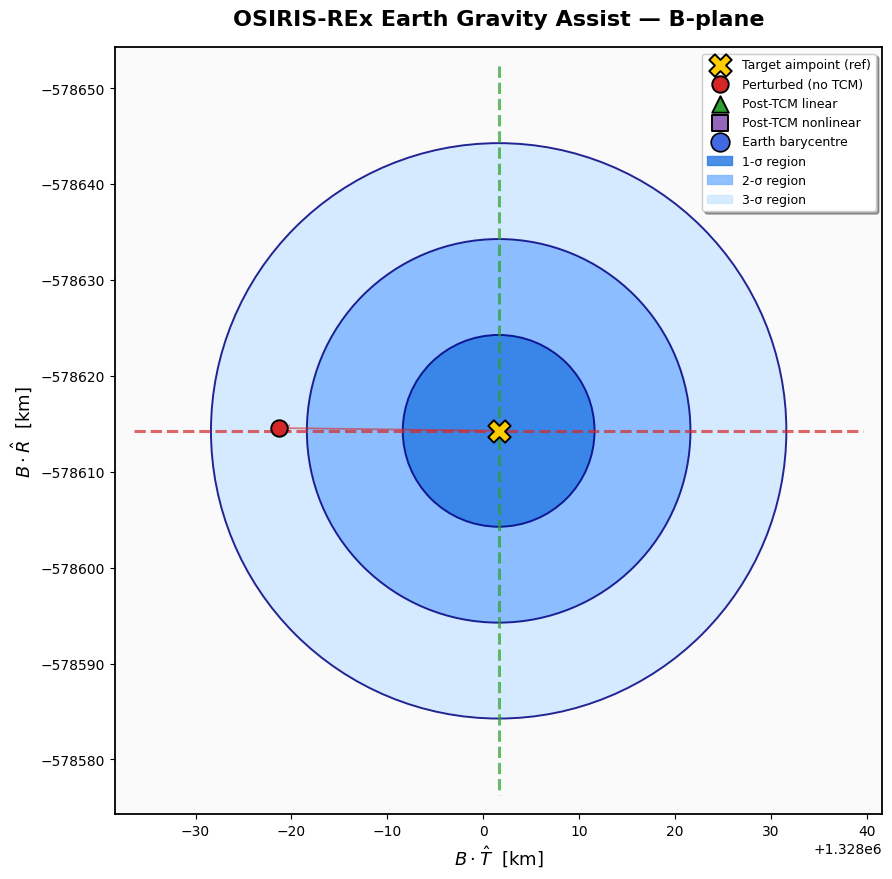

In [12]:
supp.supp_plotting.plot_bplane_covariance(BT_ref, BR_ref, BT_pert, BR_pert, BT_lin, BR_lin, BT_nl, BR_nl, rho_btbr, evec, ev, P2, maxsig, sigma_bt, sigma_br)

## Summary

| Quantity | Value |
|---------|-------|
| Target \|B\| (reference) | computed from reference SPICE state |
| Pre-TCM B-plane miss | navigation-error dependent (seed=7) |
| Post-TCM miss (linear) | ~machine precision for small errors |
| Post-TCM miss (nonlinear) | comparable to linear for this perturbation |

**Key observations**

- The B-plane mapping is highly linear for this perturbation size (~10 km / 1 cm/s),
  so linear and nonlinear TCMs give nearly identical results.
- The covariance ellipse quantifies the *expected* B-plane scatter given the assumed
  OD uncertainty, regardless of the specific draw used in the navigation-error cell.
- A real TCM design would iterate: compute covariance → assess risk → execute TCM if
  the 3-σ ellipse encroaches on exclusion zones (e.g. atmosphere / entry corridor).